# **Outlier Removal using Z score**

Normal Distribution hota h

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/placement.csv")

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
72,7.90,19.0,0
13,5.68,26.0,0
494,6.83,51.0,0
684,8.02,67.0,0
778,6.98,34.0,0


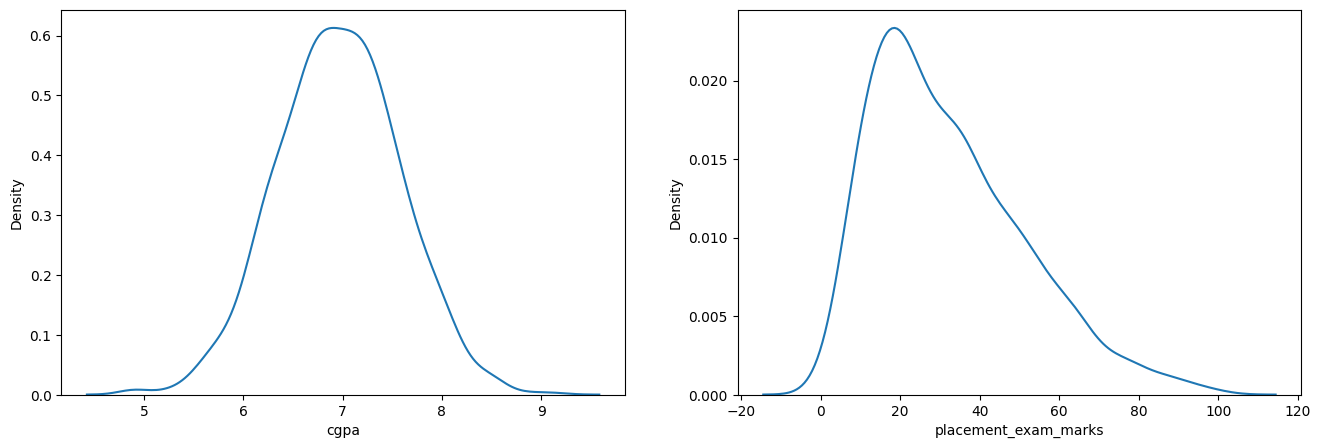

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

In [6]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [7]:
print("Highest allowed: ",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed: ",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed:  8.808933625397168
Lowest allowed:  5.113546374602832


In [8]:
df[(df['cgpa']> 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


**Trimming**

In [10]:
new_df=df[(df['cgpa']< 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [11]:
# Approach 2
# Calculate Zscore
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [12]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [14]:
df[(df['cgpa_zscore']>3) | (df['cgpa_zscore']< -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
new_df=df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


**Capping**

In [17]:
upper_limit= df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit= df['cgpa'].mean()-3*df['cgpa'].std()

In [19]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [20]:
df.shape

(1000, 4)

In [21]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934


# **Using IQR method **

In [22]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

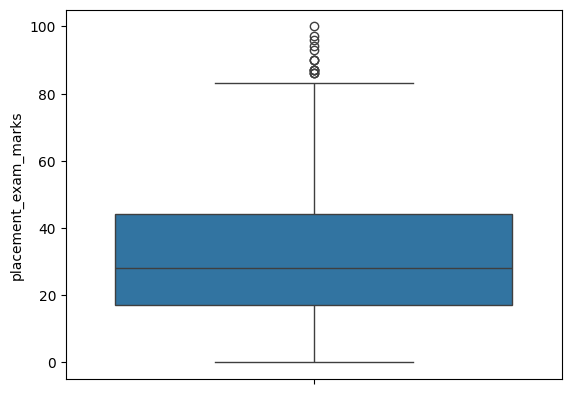

In [24]:
sns.boxplot(df['placement_exam_marks'])

In [25]:
Q1=df['placement_exam_marks'].quantile(0.25)
Q3=df['placement_exam_marks'].quantile(0.75)

In [26]:
Q3

np.float64(44.0)

In [28]:
IQR=Q3-Q1
IQR

np.float64(27.0)

In [29]:
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR

In [30]:
upper_limit

np.float64(84.5)

In [31]:
lower_limit

np.float64(-23.5)

In [32]:
df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks']<lower_limit)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [33]:
new_df=df[df['placement_exam_marks']<upper_limit]

In [34]:
new_df.shape

(985, 4)

<Axes: ylabel='placement_exam_marks'>

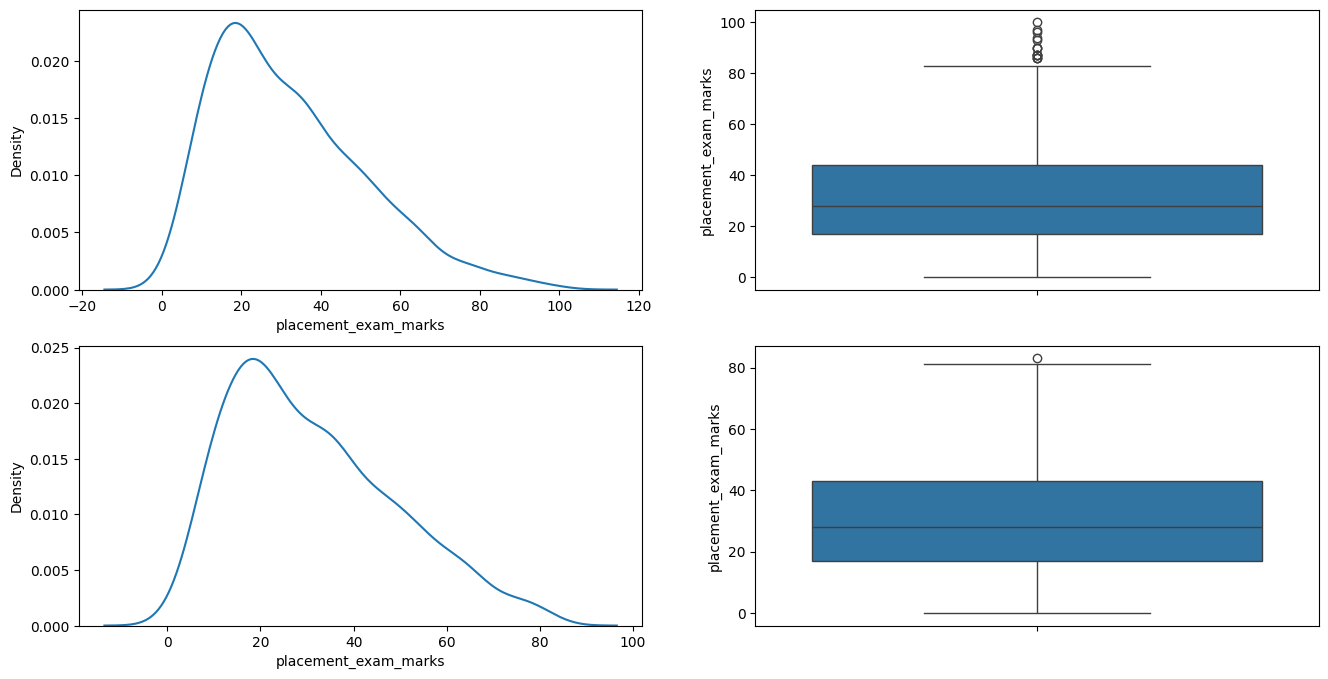

In [35]:
plt.figure(figsize=(16,8))
plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])
plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(223)
sns.kdeplot(new_df['placement_exam_marks'])
plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])

In [37]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

<Axes: ylabel='placement_exam_marks'>

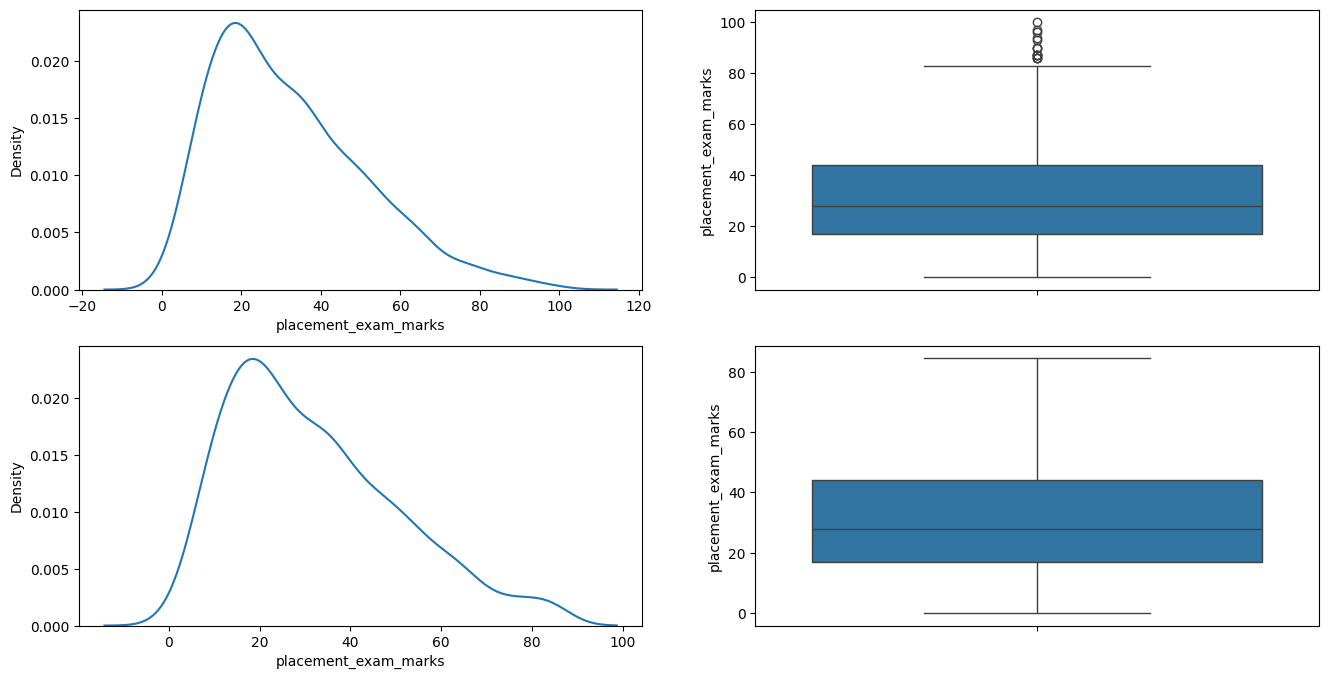

In [38]:
plt.figure(figsize=(16,8))
plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])
plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(223)
sns.kdeplot(new_df_cap['placement_exam_marks'])
plt.subplot(224)
sns.boxplot(new_df_cap['placement_exam_marks'])

# **Percentile Method**

In [39]:
data=pd.read_csv('/content/weight-height.csv')

In [40]:
data.shape

(10000, 3)

In [41]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [42]:
data['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Density'>

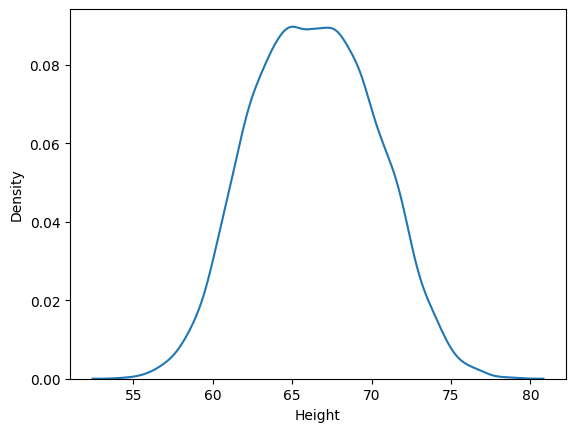

In [43]:
sns.kdeplot(data['Height'])

<Axes: ylabel='Height'>

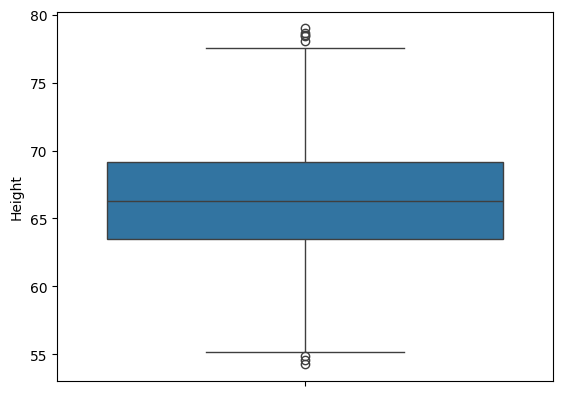

In [44]:
sns.boxplot(data['Height'])

In [45]:
upper_limit=data['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [46]:
lower_limit=data['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [49]:
new_data=data[(data['Height'] <= 74.78) & (data['Height'] >= 58.13)]

In [50]:
new_data['Height'].describe()

,Height
count,9799.000000
mean,66.363507
std,3.644267
min,58.134496
25%,63.577147
50%,66.317899
75%,69.119859
max,74.767447


<Axes: xlabel='Height', ylabel='Density'>

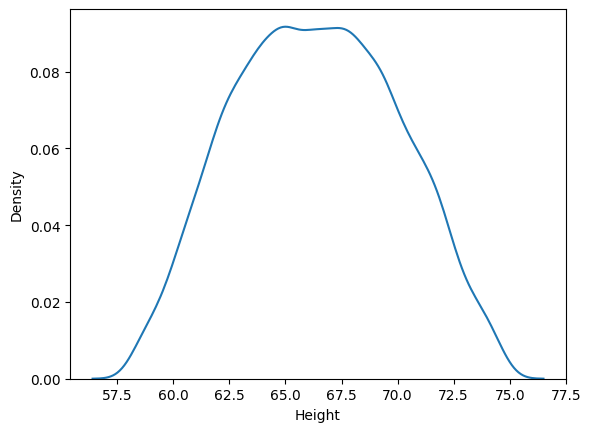

In [51]:
sns.kdeplot(new_data['Height'])

<Axes: ylabel='Height'>

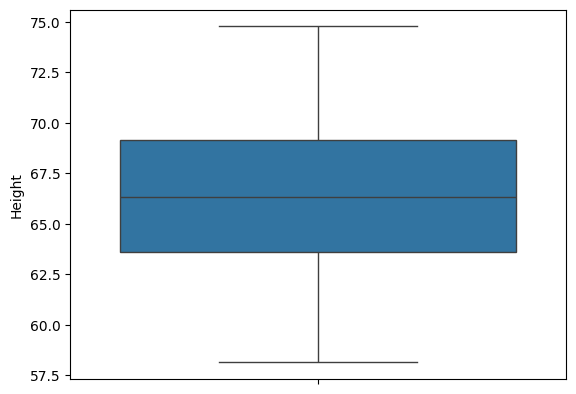

In [52]:
sns.boxplot(new_data['Height'])